# Variant Interpretation with DeepSHAP

This notebook shows how to interpret D-LDSC predictions using DeepSHAP.

In [1]:
import sys
import os
import shap
import torch
import zarr
import pickle
import pandas as pd
import numpy as np

In [2]:
sys.path.append(os.path.abspath("../.."))

In [3]:
from src.model.mlp import MLP_Baseline
from src.data.dataloader import Annotation_Dataset, GWAS_Dataset, DLDSC_DataLoader
from src.plot.finemapping_plots import plot_manhattan, plot_pip, plot_priors
from src.plot.shap_plots import plot_waterfall

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

### Load Data 

Define paths to the 4 inputs.
1. GWAS summary statistics
2. Variant annotations
3. Signed LD matrix
4. Index file

In [5]:
gwas_path = "/scratch4/davidwang/datasets/ukbb/gwas/all_traits_z_scores.parquet"
annot_path = "/scratch4/davidwang/datasets/ukbb/annotation/all/scores.meta.tsv"
ld_path = "/scratch4/davidwang/datasets/ukbb/ld_matrix/ukbb_zscores.zarr"
index_path = "/scratch4/davidwang/datasets/ukbb/index/ALL_MAF:0.01_Z:80_INFO:0.6_SQ.idx"

Create the data objects. This uses lazy loading so it should only take a few seconds.

In [6]:
# Load traits and annotation list.
traits = pd.read_csv("../all_traits.txt", header=None, dtype="str")[0].values
features = pd.read_csv("../scores.baseline.txt", header=None, sep="\t")[0].values
# Create GWAS data object.
gwas_data = GWAS_Dataset(gwas_path, traits=traits) # should reprocess these into chr and float32. Then set up indexing docs.
# Create annotation data object.
annot_data = Annotation_Dataset(pd.read_csv(annot_path, sep="\t"), features=features)
# Create LD matrix data object. 
ld_data = zarr.open(ld_path, mode="r")
# Load index
with open(index_path, "rb") as f: index = pickle.load(f)

Create the dataloader and load a window of interest.

In [7]:
window = pd.DataFrame({"chr": [8], "id": ["chr8_20000001_23000001"]})
dataloader = DLDSC_DataLoader(gwas_data, annot_data, ld_data, window, index, meta=True) 

Get the annotation, zscores, LD matrix, and metadata.

In [8]:
annot, zscore, R, _, _, metadata = next(iter(dataloader))
print(f"{metadata.shape[0]} variants in locus.")
print(f"{annot.shape[1]} annotations loaded.")

4039 variants in locus.
187 annotations loaded.


### Functional Fine-mapping

Compare results for functional and non-function finemapping from inference pass.

In [9]:
fm_res_non_funct = pd.read_parquet("../data/chr8_20000001_23000001.non_funct.parquet")
fm_res_funct = pd.read_parquet("../data/chr8_20000001_23000001.funct.parquet")

In [10]:
trait = "blood_RED_COUNT"  
zscore_rbc = zscore[:,np.where(traits == trait)[0]].squeeze().numpy()
pip_rbc_non_funct = fm_res_non_funct[trait + "_PIP"].values
cs_rbc_non_funct = fm_res_non_funct[trait + "_CS"].values
pip_rbc_funct = fm_res_funct[trait + "_PIP"].values
cs_rbc_funct = fm_res_funct[trait + "_CS"].values
prior_rbc_funct = fm_res_funct[trait + "_prior"].values

Examine the Manhattan plot. There's definitely a strong signal here. What happens if we try to fine-map it?

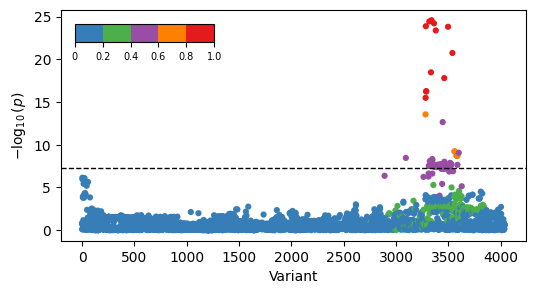

In [11]:
plot_manhattan(zscore_rbc, R[3317,:].cpu().detach().numpy(), mode="pval",legend_loc="upper left")

When we try non-functional fine-mapping, the model is very uncertain. There are 5 variants in high LD and we cannot tell which one is causal. This results in a large credible set.

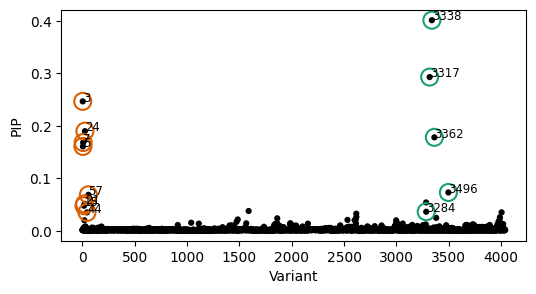

In [12]:
plot_pip(pip_rbc_non_funct, cs=cs_rbc_non_funct, show_labels=True)

When we do functional fine-mapping, we can identify the causal variant.

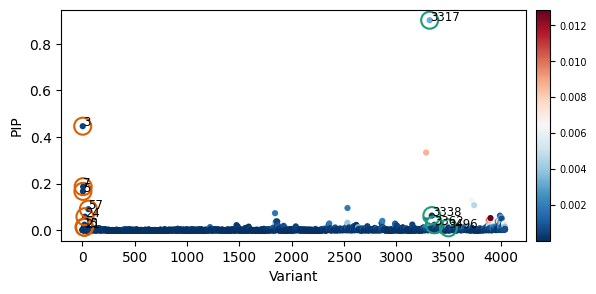

In [13]:
plot_pip(pip_rbc_funct, priors=prior_rbc_funct, cs=cs_rbc_funct, show_labels=True)

The model predicted a higher prior for variant 3317 than the others in the credible set.

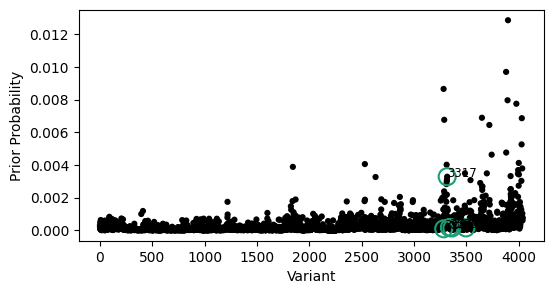

In [14]:
plot_priors(prior_rbc_funct, index=[3284, 3317, 3338, 3362, 3496], show_labels=True)

Functional fine-mapping helped us resolve uncertainty in a credible set! But why was this variant functional? Let's use DeepSHAP to find out.

### DeepSHAP

Load a trained model and set it to eval mode.

In [15]:
trained_model = "../data/ALL_MAF:0.01_Z:80_INFO:0.6_SQ_BASELINE_PRETRAIN_LR:1e-5_VAL:1-22_SI.best.pth"
model_baseline = MLP_Baseline(187, 49)
model_baseline.load_state_dict(torch.load(trained_model, map_location=device))
model_baseline.eval()

MLP_Baseline(
  (layers): Sequential(
    (0): Linear(in_features=187, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.0, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.0, inplace=False)
    (6): Linear(in_features=64, out_features=32, bias=True)
    (7): ReLU()
    (8): Dropout(p=0.0, inplace=False)
    (9): Linear(in_features=32, out_features=16, bias=True)
    (10): ReLU()
    (11): Dropout(p=0.0, inplace=False)
    (12): Linear(in_features=16, out_features=49, bias=True)
  )
)

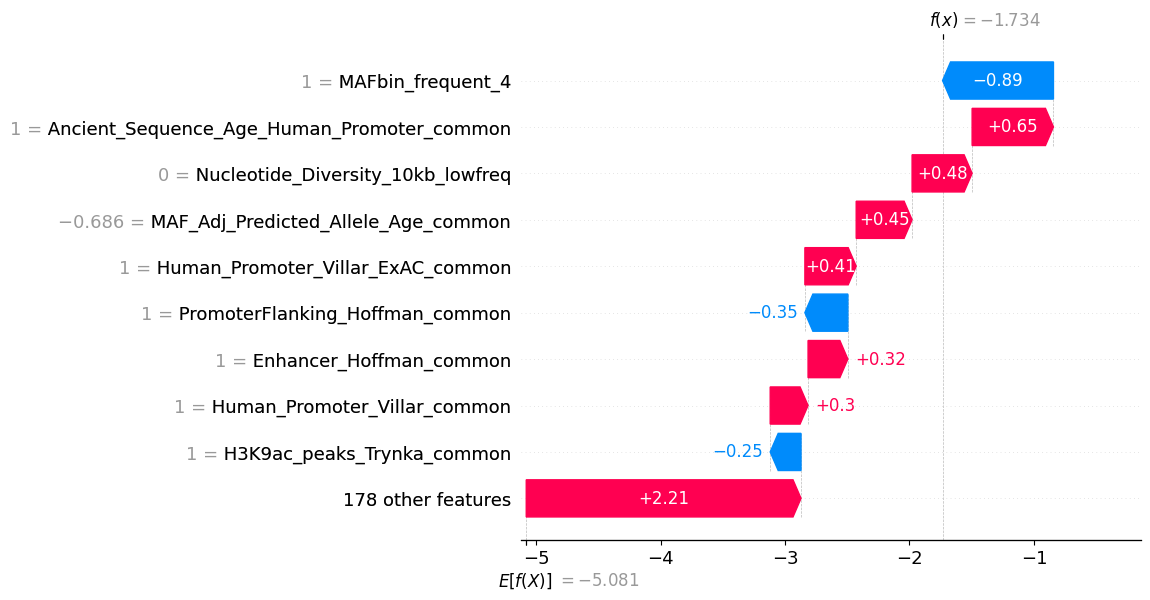

In [16]:
plot_waterfall(model_baseline, annot, features, 15, 3317)

This variant is in the promoter of XPO7. View in genome browser to confirm this is correct: 
https://genome.ucsc.edu/cgi-bin/hgTracks?db=hg19&lastVirtModeType=default&lastVirtModeExtraState=&virtModeType=default&virtMode=0&nonVirtPosition=&position=chr8%3A21774937%2D21784936&hgsid=3827373537_EY2ie67tCNrTgYeYFvv7Cv9qAStm